In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


In [24]:
#Load Dataset
df=pd.read_csv('/Users/tejasmac/ML Projects/Delhi NCR House Price Prediction/data/housing_cleaned.csv')

### EDA

In [25]:
print(df.head())

        price  bhk  area_sqft  parking
0   9500000.0  3.0     1400.0      0.0
1  57500000.0  3.0     1400.0      0.0
2   4000000.0  3.0     1400.0      0.0
3  13800000.0  4.0     1400.0      0.0
4  11000000.0  4.0     1400.0      0.0


In [26]:
print(df.describe())

              price           bhk      area_sqft       parking
count  1.200000e+04  12000.000000   12000.000000  12000.000000
mean   3.153475e+07      3.089917    1640.961417      0.691583
std    5.002292e+07      0.932597    2229.662233      0.461859
min    7.500000e+05      1.000000      32.000000      0.000000
25%    7.700000e+06      3.000000     900.000000      0.000000
50%    1.865000e+07      3.000000    1400.000000      1.000000
75%    3.470000e+07      4.000000    1900.000000      1.000000
max    1.500000e+09     12.000000  109000.000000      1.000000


In [27]:
print(df.shape)

(12000, 4)


In [28]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   price      12000 non-null  float64
 1   bhk        12000 non-null  float64
 2   area_sqft  12000 non-null  float64
 3   parking    12000 non-null  float64
dtypes: float64(4)
memory usage: 375.1 KB
None


In [29]:
print(df.columns)

Index(['price', 'bhk', 'area_sqft', 'parking'], dtype='str')


In [30]:
print(df.isna().sum())

price        0
bhk          0
area_sqft    0
parking      0
dtype: int64


Detailed EDA and visualizations were performed in the Linear Regression notebook.
This notebook focuses on Decision Tree Regression using the same cleaned dataset.

In [31]:
X=df[["bhk","area_sqft","parking"]]
y=df["price"]


In [55]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [56]:
from sklearn.tree import DecisionTreeRegressor

model=DecisionTreeRegressor()

In [57]:
model.fit(X_test,y_test)
print("Model trained successfully!✅")

Model trained successfully!✅


In [58]:
y_pred=model.predict(X_test)
print(y_pred)

[26784000.         45004545.45454545  3802181.81818182 ...
 12388888.88888889 22180000.         36121505.37634408]


In [59]:
#MAE

from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test,y_pred)
print(f"MAE:₹{mae:,.2f}")

MAE:₹6,754,161.07


In [37]:
#MSE & RMSE
from sklearn.metrics import mean_squared_error

mse=mean_squared_error(y_test,y_pred)

rmse=np.sqrt(mse)

print(f"MSE:{mse:,.2f}")
print(f"RMSE:₹{rmse:,.2f}")

MSE:234,043,096,587,362.72
RMSE:₹15,298,467.13


In [38]:
#R2
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)

print(f"R² Score : {r2:.3f}")

R² Score : 0.865


In [60]:
#Tuning Loop

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

CRORE=1e7


results = []

for depth in [2, 3, 5, 7, 10, 15, None]:

    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    current_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, current_pred)/CRORE
    rmse = np.sqrt(mean_squared_error(y_test, current_pred))/CRORE
    r2 = r2_score(y_test, current_pred)

    results.append([depth, mae, rmse, r2])

results = pd.DataFrame(
    results,
    columns=["Depth", "MAE(₹Cr)", "RMSE(₹Cr)", "R²"]
)


results=results.round(2)

print(results)

   Depth  MAE(₹Cr)  RMSE(₹Cr)    R²
0    2.0      1.37       2.82  0.54
1    3.0      1.19       2.54  0.63
2    5.0      1.10       2.36  0.68
3    7.0      1.07       2.38  0.67
4   10.0      1.06       2.52  0.63
5   15.0      1.06       2.51  0.64
6    NaN      1.07       2.56  0.62


In [42]:
best_model=DecisionTreeRegressor(max_depth=5,random_state=42)

In [43]:
best_model.fit(X_train, y_train)
print("Best Model Trained Successfully!✅")

Best Model Trained Successfully!✅


In [44]:
best_y_pred = best_model.predict(X_test)

In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, best_y_pred)
rmse = np.sqrt(mean_squared_error(y_test, best_y_pred))
r2 = r2_score(y_test, best_y_pred)

print(f"MAE : ₹{mae/1e7:.2f} Cr")
print(f"RMSE: ₹{rmse/1e7:.2f} Cr")
print(f"R²  : {r2:.3f}")

MAE : ₹1.10 Cr
RMSE: ₹2.36 Cr
R²  : 0.677


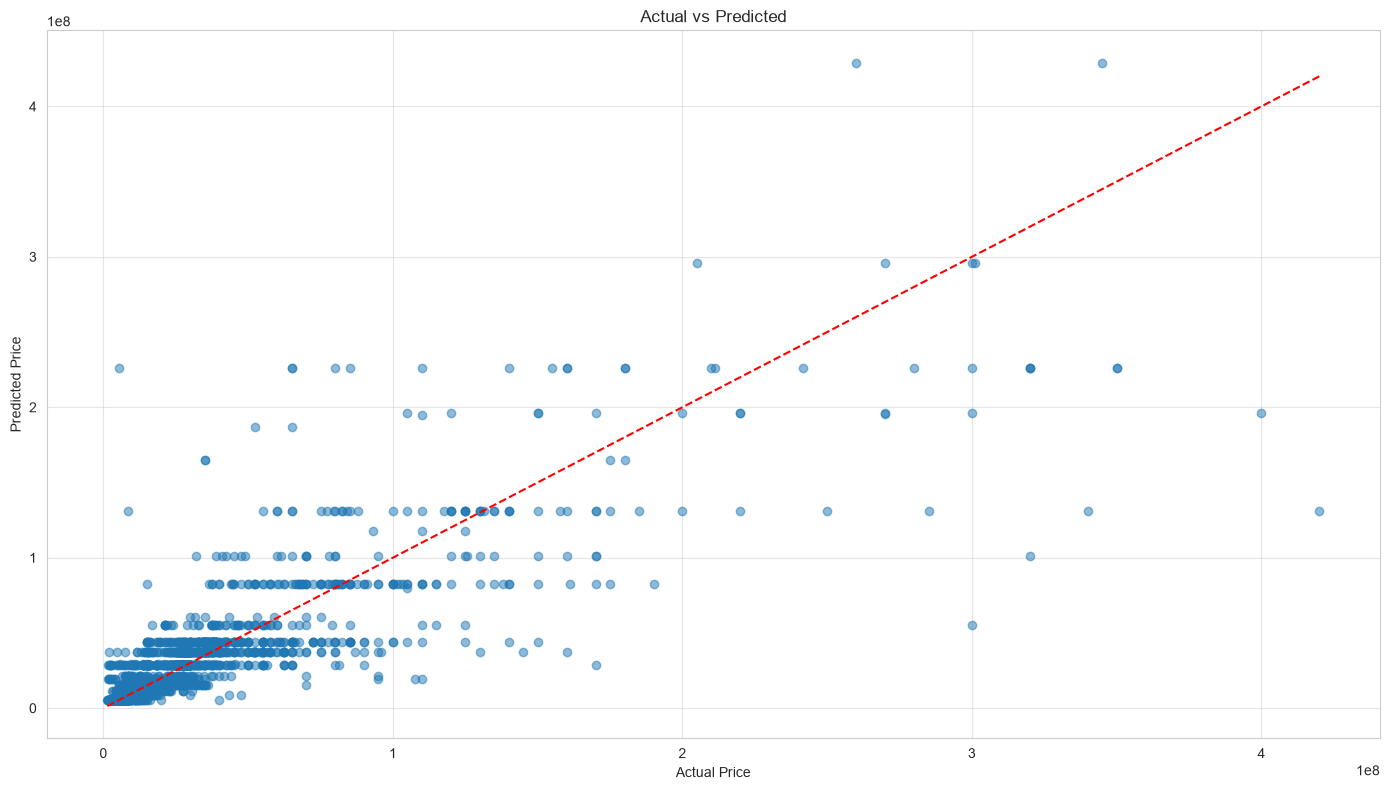

In [46]:
#Actual vs Predicted
plt.figure(figsize=(14,8))
plt.scatter(y_test,best_y_pred,alpha=0.5)

#Reference Line:

plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],
         color="red",linestyle="--"
         )

plt.grid(True,alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.tight_layout()

plt.savefig("../outputs/plots/actual_vs_predicted_dt.png", dpi=300)


plt.show()

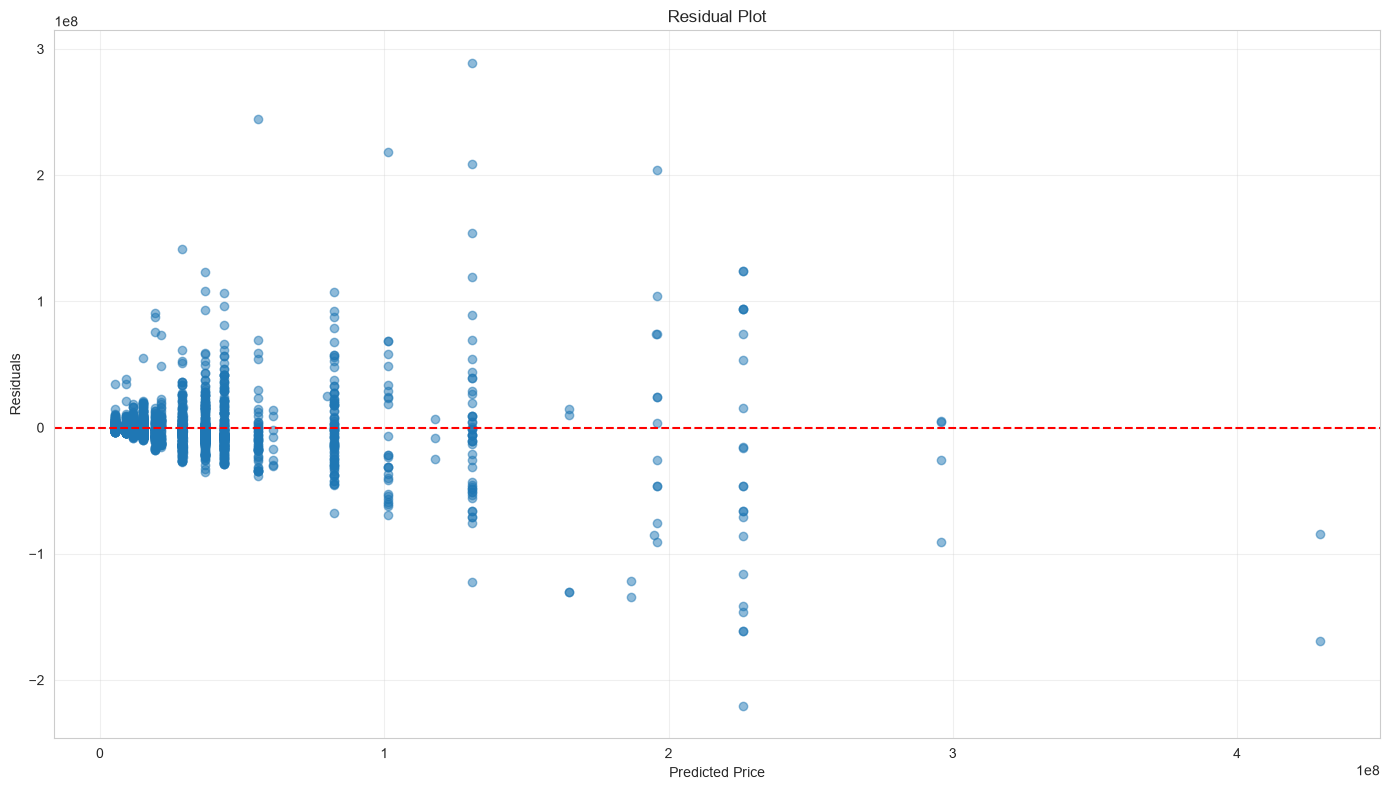

In [47]:
#Residual Plot

residuals=y_test-best_y_pred

plt.figure(figsize=(14,8))

plt.scatter(best_y_pred,residuals,alpha=0.5)
plt.axhline(y=0,color="red",linestyle="--")

plt.grid(True,alpha=0.3)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.tight_layout()

plt.savefig("../outputs/plots/residual_plot_dt.png", dpi=300)


plt.show()

In [48]:
import joblib

joblib.dump(best_model, "../models/decision_tree_model.pkl")

['../models/decision_tree_model.pkl']

In [49]:
comparison=pd.DataFrame({"Actual":[y_test],
                         "Predicted":[best_y_pred]})
comparison.to_csv("../outputs/predictions_dt.csv", index=False)

In [50]:
# User Prediction
area = float(input("Enter Area (sq ft): "))
bhk = int(input("Enter BHK: "))
parking = int(input("Enter Parking: "))

new_house = pd.DataFrame({
     "bhk": [bhk],
    "area_sqft": [area],
    "parking": [parking]
})

prediction = best_model.predict(new_house)

print("----------- Prediction -----------")
print(f"Area      : {area} sq ft")
print(f"BHK       : {bhk}")
print(f"Parking   : {parking}")
print("----------------------------------")
print(f"Estimated Price : ₹{prediction[0]/1e7:.2f}Cr")

----------- Prediction -----------
Area      : 200.0 sq ft
BHK       : 2
Parking   : 2
----------------------------------
Estimated Price : ₹2.93Cr
